In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from umap import UMAP
from poisson_utils import *

from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.mixture import GaussianMixture
from sklearn.metrics import adjusted_rand_score

In [2]:
df = pd.read_csv('00_authors.csv').rename(columns={'Unnamed: 0': 'Author'})
authors = df['Author'].values  # n_samples-length array
X = df.drop(columns=["BookID", "Author"]).values  
true_labels = pd.factorize(df["Author"])[0]
feature_names = df.drop(columns=["Author", "BookID"]).columns

# UMAP dimensionality reduction
umap_model = UMAP(n_neighbors=10, min_dist=0.3, random_state=42, n_jobs=1)
X_umap = umap_model.fit_transform(X)

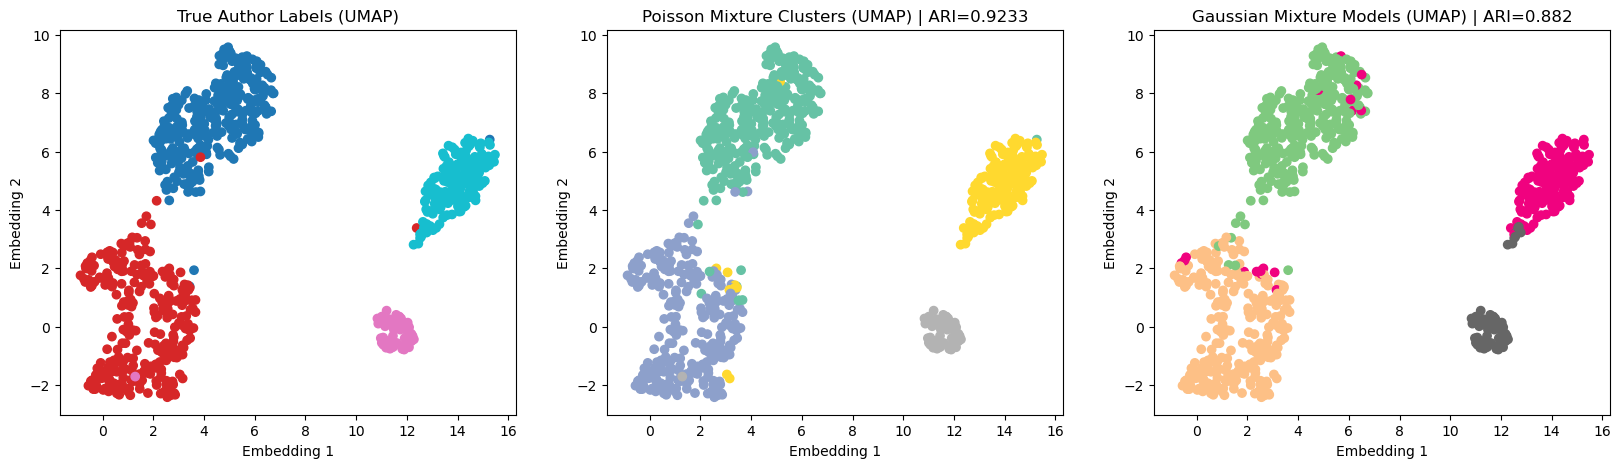

Poisson ARI: 0.9233262435084179
Gaussian ARI: 0.881998707010658


In [9]:
K = 4
state = 42

# Poisson
w, lam, pi = poisson_mixture_em(X, K, random_state=state)
poisson_labels = pi.argmax(axis=1)
poisson_certainty = pi.max(axis=1)

# GMM
gmm = GaussianMixture(n_components=K, covariance_type='full', random_state=state)
gmm_labels = gmm.fit_predict(X)
gmm_probs = gmm.predict_proba(X)
gmm_certainty = gmm_probs.max(axis=1)

fig, axes = plt.subplots(1,3,figsize=(20,5))

# 3 different fixed palettes
cmap_true   = plt.cm.tab10
cmap_pois   = plt.cm.Set2
cmap_gauss  = plt.cm.Accent

# True authors
axes[0].scatter(X_umap[:,0], X_umap[:,1], c=true_labels, cmap=cmap_true)
axes[0].set_title("True Author Labels (UMAP)")
axes[0].set_xlabel('Embedding 1')
axes[0].set_ylabel('Embedding 2')

# Poisson clusters
ari_pois = adjusted_rand_score(true_labels, poisson_labels)
axes[1].scatter(X_umap[:,0], X_umap[:,1], c=poisson_labels, cmap=cmap_pois)
axes[1].set_title(f"Poisson Mixture Clusters (UMAP) | ARI={round(ari_pois,4)}")
axes[1].set_xlabel('Embedding 1')
axes[1].set_ylabel('Embedding 2')

ari_gmm = adjusted_rand_score(true_labels, gmm_labels)
axes[2].scatter(X_umap[:,0], X_umap[:,1], c=gmm_labels, cmap=cmap_gauss)
axes[2].set_title(f"Gaussian Mixture Models (UMAP) | ARI={round(ari_gmm,4)}")
axes[2].set_xlabel('Embedding 1')
axes[2].set_ylabel('Embedding 2')

plt.show()

print("Poisson ARI:", adjusted_rand_score(true_labels, poisson_labels))
print("Gaussian ARI:", adjusted_rand_score(true_labels, gmm_labels))

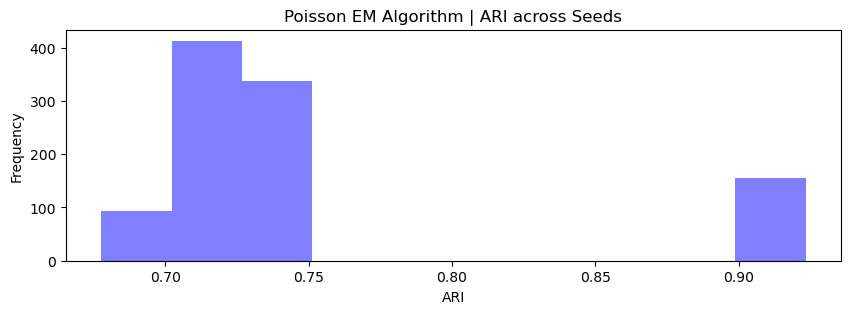

In [10]:
scores_dict = {}
for seed in range(1000):
    w, lam, pi = poisson_mixture_em(X, K, random_state=seed)
    labels = pi.argmax(axis=1)
    scores_dict[seed] = adjusted_rand_score(true_labels, labels)

plt.figure(figsize=(10,3))
plt.hist(scores_dict.values(),bins=10,color='blue',alpha=0.5)
plt.title('Poisson EM Algorithm | ARI across Seeds')
plt.ylabel('Frequency')
plt.xlabel('ARI')
plt.show()

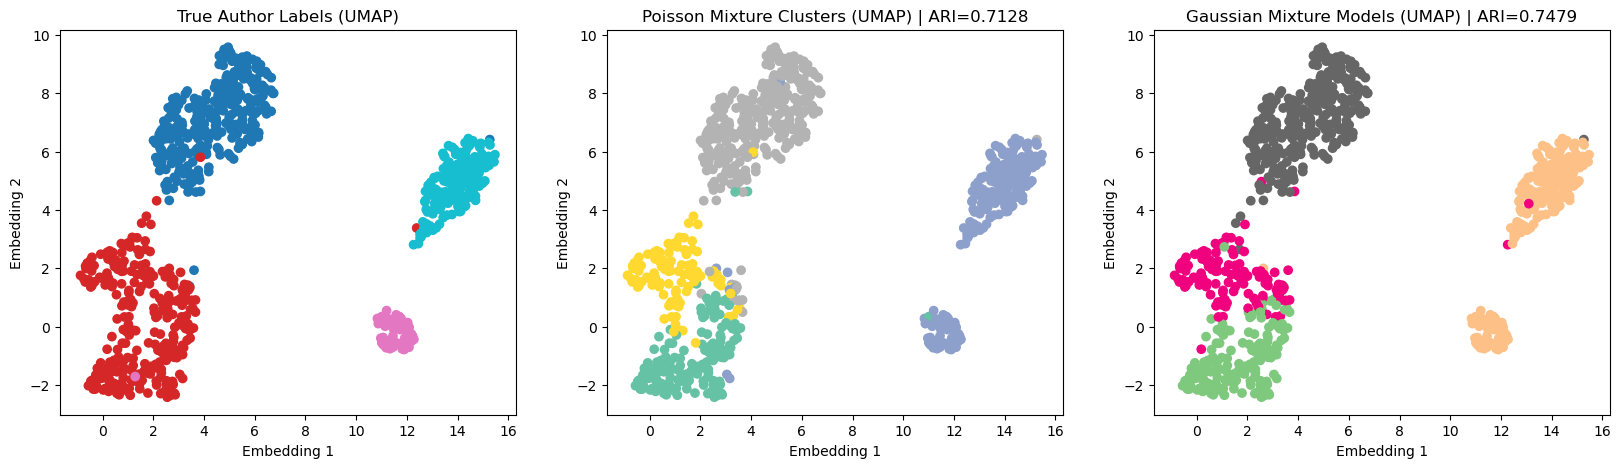

Poisson ARI: 0.712845675387507
Gaussian ARI: 0.747897482717644


In [11]:
K = 4
state = 0

# Poisson
w, lam, pi = poisson_mixture_em(X, K, random_state=state)
poisson_labels = pi.argmax(axis=1)
poisson_certainty = pi.max(axis=1)

# GMM
gmm = GaussianMixture(n_components=K, covariance_type='full', random_state=state)
gmm_labels = gmm.fit_predict(X)
gmm_probs = gmm.predict_proba(X)
gmm_certainty = gmm_probs.max(axis=1)

fig, axes = plt.subplots(1,3,figsize=(20,5))

# 3 different fixed palettes
cmap_true   = plt.cm.tab10
cmap_pois   = plt.cm.Set2
cmap_gauss  = plt.cm.Accent

# True authors
axes[0].scatter(X_umap[:,0], X_umap[:,1], c=true_labels, cmap=cmap_true)
axes[0].set_title("True Author Labels (UMAP)")
axes[0].set_xlabel('Embedding 1')
axes[0].set_ylabel('Embedding 2')

# Poisson clusters
ari_pois = adjusted_rand_score(true_labels, poisson_labels)
axes[1].scatter(X_umap[:,0], X_umap[:,1], c=poisson_labels, cmap=cmap_pois)
axes[1].set_title(f"Poisson Mixture Clusters (UMAP) | ARI={round(ari_pois,4)}")
axes[1].set_xlabel('Embedding 1')
axes[1].set_ylabel('Embedding 2')

ari_gmm = adjusted_rand_score(true_labels, gmm_labels)
axes[2].scatter(X_umap[:,0], X_umap[:,1], c=gmm_labels, cmap=cmap_gauss)
axes[2].set_title(f"Gaussian Mixture Models (UMAP) | ARI={round(ari_gmm,4)}")
axes[2].set_xlabel('Embedding 1')
axes[2].set_ylabel('Embedding 2')

plt.show()

print("Poisson ARI:", adjusted_rand_score(true_labels, poisson_labels))
print("Gaussian ARI:", adjusted_rand_score(true_labels, gmm_labels))

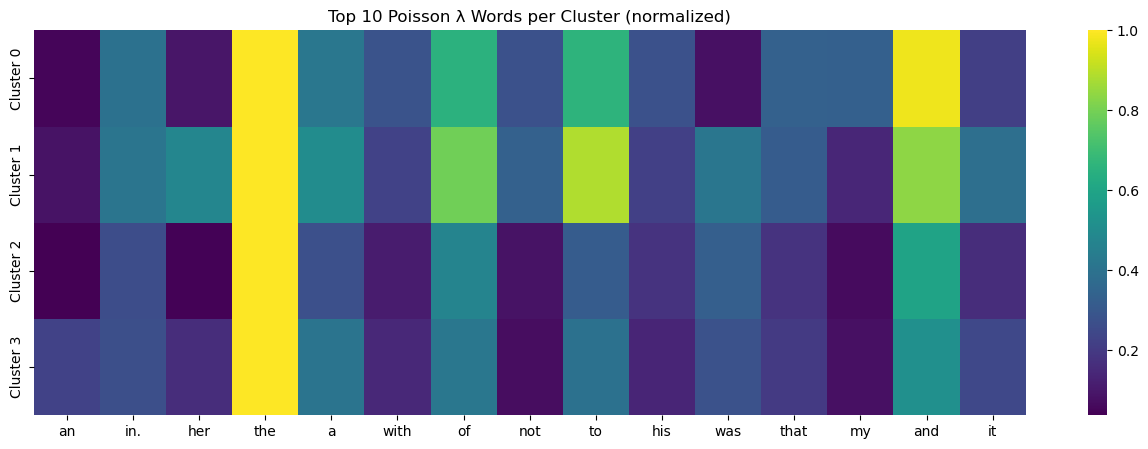

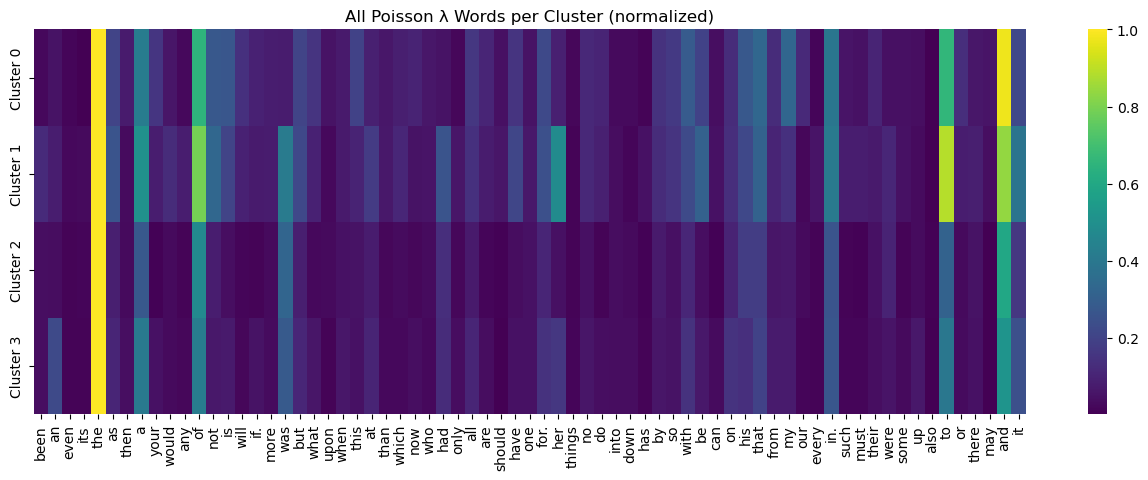

In [5]:
plot_word_heatmap(lam=lam, feature_names=feature_names, top_n=10)
plot_word_heatmap(lam=lam, feature_names=feature_names, top_n=69)

In [27]:
## Refresh w,lam,pi to the stronger solution (better intialization)
K = 4
state = 42

# Poisson
w, lam, pi = poisson_mixture_em(X, K, random_state=state)
poisson_labels = pi.argmax(axis=1)
poisson_certainty = pi.max(axis=1)

print("Poisson ARI:", adjusted_rand_score(true_labels, poisson_labels))

Poisson ARI: 0.9233262435084179


In [43]:
threshold = 0.75
uncertain_idx = np.where(poisson_certainty < threshold)[0]

print("Low-certainty chapters (Poisson):", uncertain_idx)
print("Count:", len(uncertain_idx))

Low-certainty chapters (Poisson): [ 32 332 385 413 526 767]
Count: 6


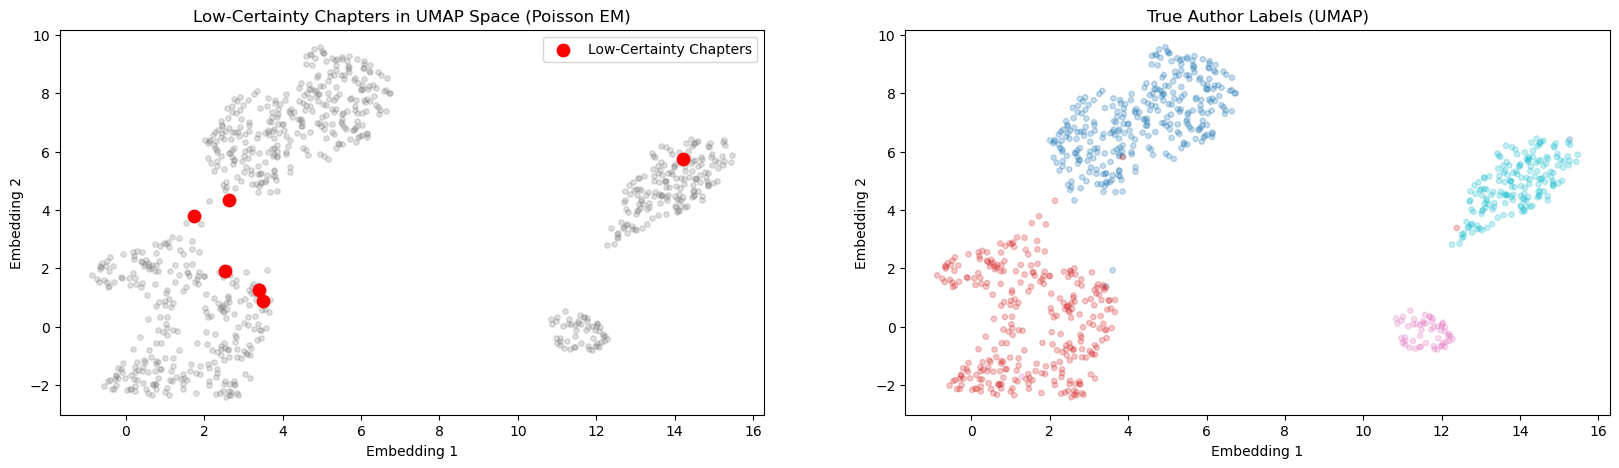

In [49]:
fig, axes = plt.subplots(1,2,figsize=(20,5))

# 3 different fixed palettes
cmap_true   = plt.cm.tab10
cmap_pois   = plt.cm.Set2

# Uncertain chapters
axes[0].scatter(X_umap[:,0], X_umap[:,1], alpha=0.25, s=15, color='grey')
axes[0].scatter(X_umap[uncertain_idx,0], X_umap[uncertain_idx,1],
            color='red', s=80, label='Low-Certainty Chapters')
axes[0].set_title("Low-Certainty Chapters in UMAP Space (Poisson EM)")
axes[0].legend()
axes[0].set_xlabel('Embedding 1')
axes[0].set_ylabel('Embedding 2')

# True authors
axes[1].scatter(X_umap[:,0], X_umap[:,1], c=true_labels, cmap=cmap_true,alpha=0.25, s=15)
axes[1].set_title("True Author Labels (UMAP)")
axes[1].set_xlabel('Embedding 1')
axes[1].set_ylabel('Embedding 2')

plt.show()